In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

# Load in processed anndata

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.42 GB, difference +2.42 GB
CPU times: user 496 ms, sys: 2 s, total: 2.5 s
Wall time: 5.63 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [3]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
regev_genes = [g for g in regev_genes if g in adata.var_names]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:01)
computing score 'G2M_score'
    finished (0:00:01)
CPU times: user 1.76 s, sys: 1.44 s, total: 3.2 s
Wall time: 3.23 s


,phase
AAACCAAAGCAACTGC_hybrid,G2M
AAACCAAAGTAGGGCA_hybrid,S
AAACCAAAGTCTAGGC_hybrid,G1
AAACCATTCACGTAAT_hybrid,G2M
AAACCATTCAGGCAGA_hybrid,G2M


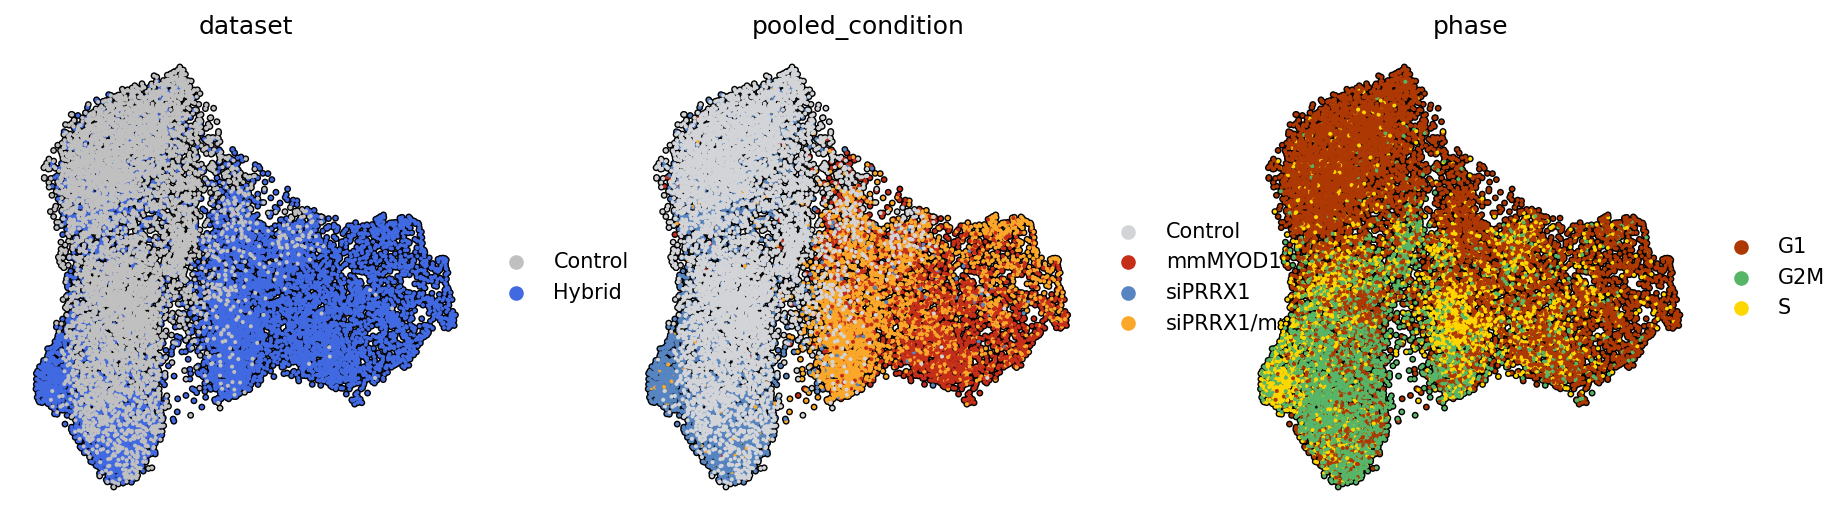

In [4]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'phase'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

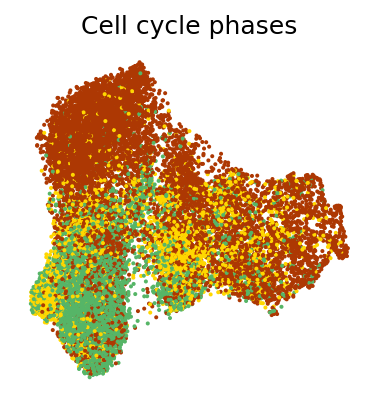

In [15]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    color='phase',
    size=15,
    # add_outline=True,
    # outline_color=('k', 'k'),
    frameon=False, 
    # alpha=0.9,
    title="Cell cycle phases",
    # palette=dataset_colors,
    legend_loc='none',
)

condition_by_phase_group
Control_G1/S            5132
mmMYOD1_G1/S            2051
siPRRX1_G1/S            2502
siPRRX1/mmMYOD1_G1/S    2939
Control_G2/M            1770
mmMYOD1_G2/M             204
siPRRX1_G2/M            1181
siPRRX1/mmMYOD1_G2/M     517
Name: count, dtype: int64


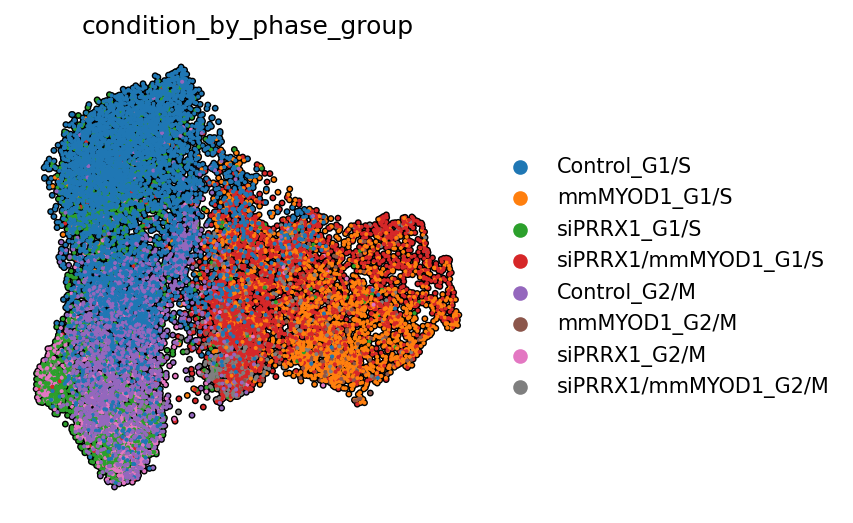

In [5]:
phase_group_map = {
    "G1": "G1/S",
    "S": "G1/S",
    "G2M": "G2/M"
}

adata.obs["condition_by_phase_group"] = (
    adata.obs["pooled_condition"].astype(str) + "_" +
    adata.obs["phase"].map(phase_group_map)
)

# Make categorical and optionally order
conditions = ["Control", "mmMYOD1", "siPRRX1", "siPRRX1/mmMYOD1"]
phase_groups = ["G1/S", "G2/M"]
ordered_categories = [f"{cond}_{ph}" for ph in phase_groups for cond in conditions]

adata.obs["condition_by_phase_group"] = pd.Categorical(
    adata.obs["condition_by_phase_group"],
    categories=ordered_categories,
    ordered=True
)

print(adata.obs["condition_by_phase_group"].value_counts(sort=False))

sc.pl.umap(
    adata,
    color=['condition_by_phase_group'],
    size=15,
    # ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Load in gene sets

In [6]:
fpath = "../../resources/genes_for_scoring.csv"

df = pd.read_csv(fpath)
print(df.shape)
print(df.columns.tolist())
df.head()

qui_tfs = [gene for gene in df['quiescence'].unique() if gene in adata.var_names]
print(f"\nN quiescence TFs: {len(qui_tfs)}")

(512, 18)
['G1/S_transition', 'G2/M_transition', 'CC_checkpoints', 'Cell_cycle_reg', 'Pos_proliferation', 'Neg_proliferation', 'quiescence', 'AS', 'Chromatin', 'Circadian', 'Core_repro', 'NOTCH_signaling', 'Asymm_PCP', 'FOXO', 'p53_acyivity', 'DREAM/negE2F', 'senes_stress', 'sasp']

N quiescence TFs: 59


In [7]:
fpath = "../../resources/quiescence_markers.csv"

qdf = pd.read_csv(fpath)
print(qdf.shape)
qdf.head()

print(qdf['source'].value_counts())

# remove these genes because specific to stem cell quiescence ? 
qdf = qdf[qdf['source'] != 'Cheung_down']
qdf = qdf[qdf['source'] != 'Cheung_up']

qdf_up = qdf[qdf['source'].str.endswith('_up')]
qui_up_genes = qdf_up['gene'].unique()
print(f"\nN genes UP in quiescence: {len(qui_up_genes)}")

qdf_down = qdf[qdf['source'].str.endswith('_down')]
qui_down_genes = qdf_down['gene'].unique()
print(f"N genes DOWN in quiescence: {len(qui_down_genes)}")

(198, 2)
source
Coller_up      87
Cheung_up      38
G1_to_G0_up    30
Coller_down    24
Cheung_down    19
Name: count, dtype: int64

N genes UP in quiescence: 115
N genes DOWN in quiescence: 24


# Score genes

computing score 'quiescence_TFs_score'
    finished (0:00:02)
computing score 'quiescence_genes_score'
    finished (0:00:02)
computing score 'quiescence_down_score'
    finished (0:00:02)


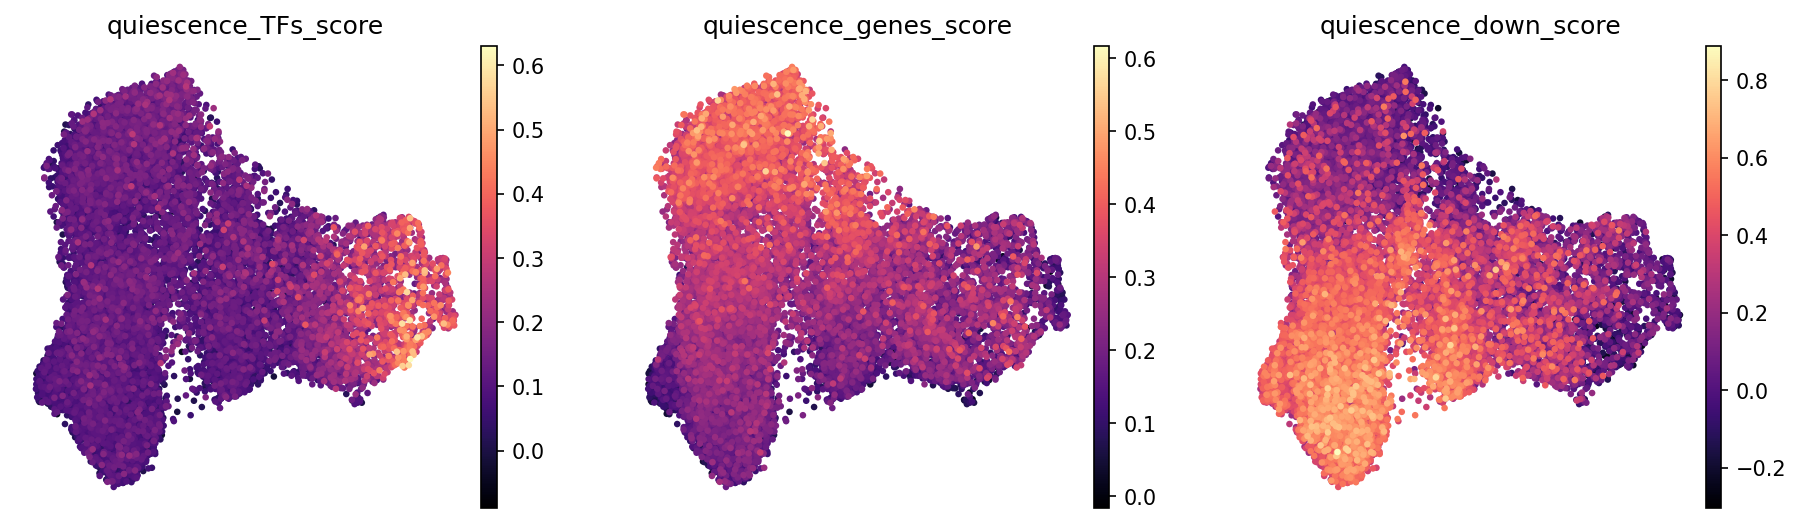

In [8]:
# qui_geneset = list(set(qui_up_genes) | set(qui_tfs))
# print(len(qui_geneset))

sc.tl.score_genes(
    adata,
    gene_list=qui_tfs,
    score_name='quiescence_TFs_score',
    ctrl_size=500,
    use_raw=False,
    layer='log_norm',
)

sc.tl.score_genes(
    adata,
    gene_list=qui_up_genes,
    score_name='quiescence_genes_score',
    ctrl_size=500,
    use_raw=False,
    layer='log_norm',
)

sc.tl.score_genes(
    adata,
    gene_list=qui_down_genes,
    score_name='quiescence_down_score',
    ctrl_size=500,
    use_raw=False,
    layer='log_norm',
)

sc.pl.umap(
    adata,
    color=['quiescence_TFs_score', 'quiescence_genes_score', 'quiescence_down_score'],
    size=40,
    ncols=3,
    # colorbar_loc=None,
    frameon=False,
    alpha=1,
    cmap='magma',
    # vmin=adata.obs['quiescence_score'].min(),
    # vmax=adata.obs['quiescence_score'].max(),
    # title='',
    # na_color='#EAE9E9',
)

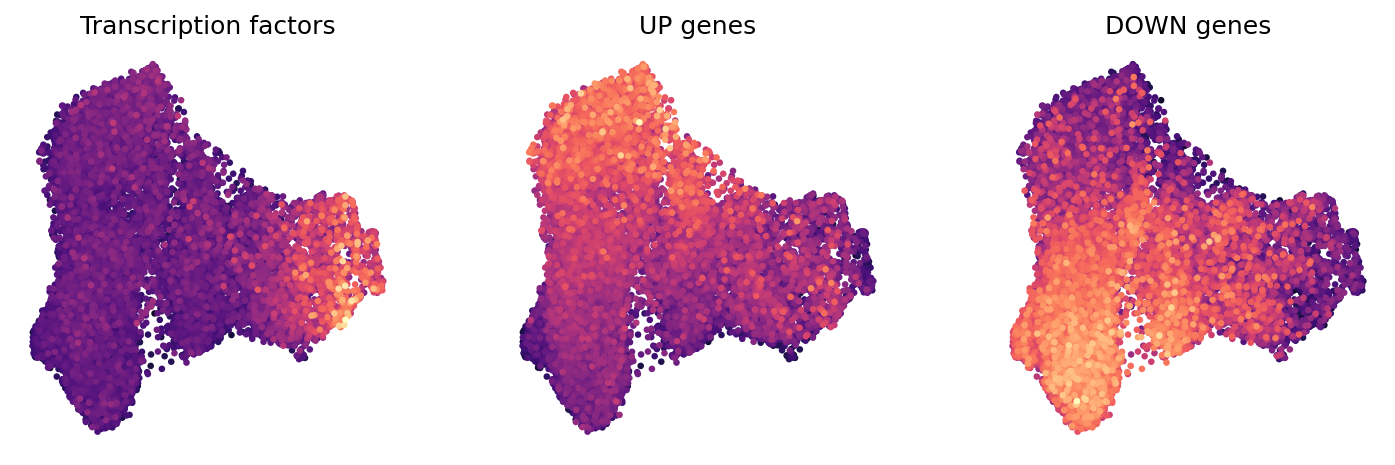

In [13]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3.5

sc.pl.umap(
    adata,
    color=['quiescence_TFs_score', 'quiescence_genes_score', 'quiescence_down_score'],
    size=40,
    ncols=3,
    colorbar_loc=None,
    frameon=False,
    alpha=1,
    cmap='magma',
    title=['Transcription factors', 'UP genes', 'DOWN genes'],
    # vmin=adata.obs['quiescence_score'].min(),
    # vmax=adata.obs['quiescence_score'].max(),
    # title='',
    # na_color='#EAE9E9',
)

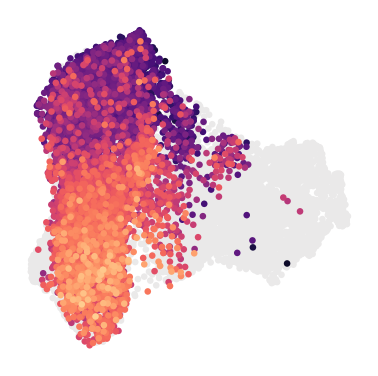

In [11]:
mask_prrx = adata.obs['pooled_condition'] == 'siPRRX1'
mask_myod = adata.obs['pooled_condition'] == 'mmMYOD1'
mask_hyb = adata.obs['pooled_condition'] == 'siPRRX1/mmMYOD1'
mask_ctrl = adata.obs['pooled_condition'] == 'Control'


plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

score_name = 'quiescence_down_score'

sc.pl.umap(
    adata,
    color=score_name,
    mask_obs=mask_ctrl,
    size=40,
    ncols=1,
    colorbar_loc=None,
    frameon=False,
    alpha=1,
    cmap='magma',
    vmin=adata.obs[score_name].min(),
    vmax=adata.obs[score_name].max(),
    title='',
    na_color='#EAE9E9',
)

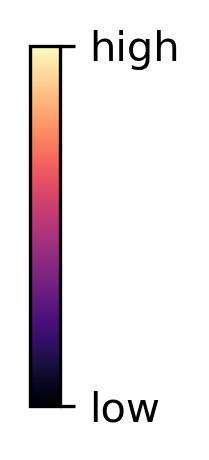

In [12]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots(figsize=(1, 2))

vmin = 0 #adata.obs[score_name].min()
vmax = 1 #adata.obs[score_name].max()

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=vmin, vmax=vmax)),
    cax=ax, orientation='vertical'
)

ax.set_position([0.2, 0.1, 0.1, 0.6]) # [left, bottom, width, height] in figure coordinates

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['low', 'high'])

# cbar.set_label("score", fontsize=11)
cbar.ax.tick_params(labelsize=10)
plt.show()

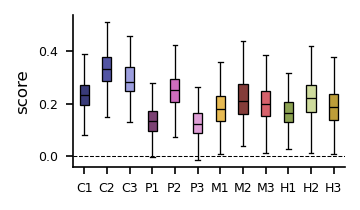

In [14]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 2.5, 1.5

cond_order = ['C1','C2', 'C3', 'P1', 'P2', 'P3', 'M1', 'M2', 'M3', 'H1', 'H2', 'H3']

score_name = 'quiescence_genes_score'
# quiescence_TFs_score
# quiescence_genes_score
# quiescence_down_score

sns.boxplot(
    data=adata.obs,
    # x='pooled_condition',
    # hue='pooled_condition',
    x='leiden_split',
    hue='leiden_split',
    order=cond_order,
    # x='condition_by_phase_group',
    # hue='condition_by_phase_group',
    y=score_name,
    width=0.4,
    linecolor='k',
    linewidth=0.63,
    palette=adata.uns['leiden_split_colors'],
    legend=False,
    saturation=1,
    showfliers=False,
    # flierprops={'markersize': 0.5, 'alpha': 0.5},
    zorder=1,
)

plt.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=0)

plt.ylabel('score', fontsize=8)
plt.xticks(fontsize=6)#, rotation=90)
plt.yticks(fontsize=6)
plt.xlabel("")
sns.despine()

plt.tight_layout()
plt.show() 

## Quiescence index

In [16]:
cols = ['pooled_condition', 'phase', 'leiden_split', 'quiescence_TFs_score', 'quiescence_genes_score', 'quiescence_down_score']

df = adata.obs[cols].copy()
df.head()

,pooled_condition,phase,leiden_split,quiescence_TFs_score,quiescence_genes_score,quiescence_down_score
AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1,G2M,H1,0.081815,0.135262,0.474370
AAACCAAAGTAGGGCA_hybrid,mmMYOD1,S,M1,0.130956,0.071959,0.193444
AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1,G1,H1,0.092294,0.279917,0.253926
AAACCATTCACGTAAT_hybrid,siPRRX1,G2M,P1,0.027587,0.131116,0.888023
AAACCATTCAGGCAGA_hybrid,siPRRX1,G2M,P1,0.061720,0.167587,0.536928


In [17]:
score_cols = cols[-3:]
score_cols

['quiescence_TFs_score', 'quiescence_genes_score', 'quiescence_down_score']

In [18]:
# z-score normalize each score across all cells
for col in score_cols:
    mean = df[col].mean()
    std = df[col].std()
    df[col + '_z'] = (df[col] - mean) / std

# compute quiescence index per cell
df['QI_cell'] = (
    df['quiescence_TFs_score_z'] +
    df['quiescence_genes_score_z'] -
    df['quiescence_down_score_z']
)

df.head()

,pooled_condition,phase,leiden_split,quiescence_TFs_score,quiescence_genes_score,quiescence_down_score,quiescence_TFs_score_z,quiescence_genes_score_z,quiescence_down_score_z,QI_cell
AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1,G2M,H1,0.081815,0.135262,0.474370,-0.262744,-1.039530,1.168147,-2.470420
AAACCAAAGTAGGGCA_hybrid,mmMYOD1,S,M1,0.130956,0.071959,0.193444,0.384055,-1.738205,-0.155810,-1.198341
AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1,G1,H1,0.092294,0.279917,0.253926,-0.124811,0.557020,0.129233,0.302975
AAACCATTCACGTAAT_hybrid,siPRRX1,G2M,P1,0.027587,0.131116,0.888023,-0.976493,-1.085294,3.117621,-5.179407
AAACCATTCAGGCAGA_hybrid,siPRRX1,G2M,P1,0.061720,0.167587,0.536928,-0.527240,-0.682768,1.462971,-2.672978


In [19]:
qi_cluster = (
    df.groupby('leiden_split', observed=True)['QI_cell']
    .mean()
    .sort_values(ascending=True)
)

qi_cluster

leiden_split
P1   -2.609155
P3   -2.364050
H1   -1.527859
C1   -0.922758
P2    0.044345
M2    0.291902
H2    0.361643
C3    0.789361
M1    0.955502
C2    1.813618
H3    2.504407
M3    3.328208
Name: QI_cell, dtype: float64

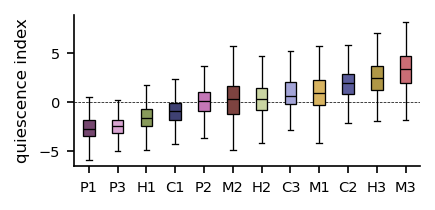

In [20]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 1.5

# cond_order = ['C1','C2', 'C3', 'P1', 'P2', 'P3', 'M1', 'M2', 'M3', 'H1', 'H2', 'H3']

cond_order = qi_cluster.index.tolist()

sns.boxplot(
    data=df,
    x='leiden_split',
    hue='leiden_split',
    order=cond_order,
    y='QI_cell',
    width=0.4,
    linecolor='k',
    linewidth=0.63,
    palette=adata.uns['leiden_split_colors'],
    legend=False,
    saturation=0.8,
    showfliers=False,
    # flierprops={'markersize': 0.5, 'alpha': 0.5},
    zorder=1,
)

plt.axhline(0, linestyle='--', linewidth=0.35, color='k', zorder=0)

plt.ylabel('quiescence index', fontsize=8)
plt.xticks(fontsize=7)#, rotation=90)
plt.yticks(fontsize=7)
plt.xlabel("")

sns.despine()
plt.tight_layout()

fig = plt.gcf()
fig.patch.set_alpha(0)  # makes figure background transparent
plt.gca().patch.set_alpha(0)
plt.show() 

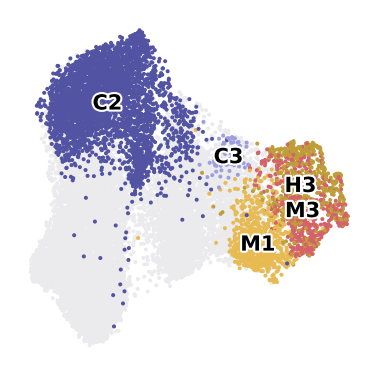

In [22]:
mask = adata.obs['leiden_split'].isin(['M3', 'H3', 'C2', 'M1', 'C3']) 

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    color='leiden_split',
    mask_obs=mask,
    size=15,
    frameon=False,
    alpha=1,
    na_color='#EBEBED',
    title='',
    # legend_loc='none',
    legend_loc='on data',
    na_in_legend=False,
    legend_fontoutline=2,
    legend_fontsize='medium',
)

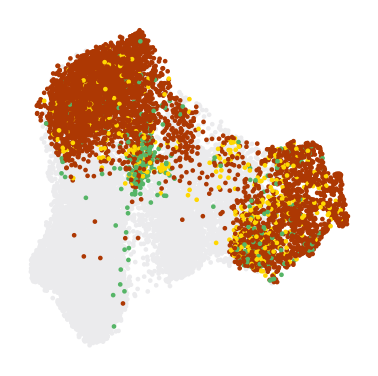

In [52]:
mask = adata.obs['leiden_split'].isin(['M3', 'H3', 'C2', 'M1', 'C3']) 

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    color='phase',
    mask_obs=mask,
    size=20,
    frameon=False,
    alpha=1,
    na_color='#EBEBED',
    title='',
    legend_loc='none',
    # legend_loc='on data',
    # na_in_legend=False,
    # legend_fontoutline=2,
    # legend_fontsize='medium',
)

In [21]:
cluster_means = df.groupby('leiden_split', observed=True)[score_cols].mean()

# z-score across clusters
cluster_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

cluster_means['QI_cell'] = (
    cluster_z['quiescence_TFs_score'] +
    cluster_z['quiescence_genes_score'] -
    cluster_z['quiescence_down_score']
)


cluster_means

,quiescence_TFs_score,quiescence_genes_score,quiescence_down_score,QI_cell
leiden_split,,,,
C1,0.091183,0.233387,0.401940,-1.425778
C2,0.101201,0.329442,0.074246,2.575863
C3,0.107915,0.288036,0.213363,1.005173
H1,0.069771,0.170336,0.322874,-2.231297
H2,0.104617,0.219619,0.134681,0.334889
H3,0.261761,0.188986,0.047152,2.399909
M1,0.159634,0.180780,0.071369,0.801878
M2,0.118439,0.218011,0.184316,0.143475
M3,0.298060,0.200822,0.001451,3.373238


# DGE

In [23]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    """ Filters DGE results for significant differentially expressed genes. 
    
    Params
    ------
        df (pd.DataFrame): Dataframe containing DGE results.
        alpha (float): Adjusted p-value threshold for statistical significance. Genes below this threshold are considered significant.
        logfc_thresh (float): Minimum absolute logfoldchange required for a gene to be considered significantly DE. 
        pct_nz_thresh (float): Minimum proportion of cells in the group of interest expressing the gene. Genes expressed in fewer cells than this threshold will be excluded.
    
    """
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]

    
    if pct_nz_thresh != 0.0:
        if 'pct_nz_reference' in tmp.columns:
            tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
        else:
            tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

In [24]:
# all groups vs each other
sc.tl.rank_genes_groups(
    adata, 
    groupby="leiden_split",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='cluster_vs_rest',
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='cluster_vs_rest',
)
print(deg.shape)

ranking genes
    finished (0:00:42)
(301512, 8)


In [25]:
sig = get_significant_DEGs(deg)#, pct_nz_thresh=0.2)
sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 11706



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc
0,C1,MZT2B,66.531631,1.570619,0.0,0.0,0.998773,0.845198,1.570619
1,C1,PFN1,66.182312,0.856354,0.0,0.0,1.000000,0.989874,0.856354
2,C1,HMGB1,65.278023,1.261719,0.0,0.0,1.000000,0.969853,1.261719
3,C1,MT-ND4L,63.074718,3.035329,0.0,0.0,0.997853,0.583461,3.035329
4,C1,TOP2A,60.939571,2.697410,0.0,0.0,0.950307,0.488033,2.697410


In [26]:
all_qui = list(set(qui_tfs) | set(qui_down_genes) | set(qui_up_genes))
print(len(all_qui))

all_qui_dict = {
    'TF': qui_tfs,
    'down': qui_down_genes,
    'up': qui_up_genes,
}


sig = sig[sig['names'].isin(all_qui)]
print(sig['names'].nunique())

196
165


In [27]:
# look at H3 and M3

groups = ['H3', 'M3']

pdf = sig[sig['group'].isin(groups)]
pdf.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc
125632,H3,ATF3,36.009872,5.547523,5.860824e-284,4.908636e-280,0.950000,0.209329,5.547523
125640,H3,JUN,32.371319,3.206012,6.954433e-230,6.025416e-227,0.944643,0.537938,3.206012
125655,H3,IL6,28.660162,3.620984,1.197621e-180,3.039537e-178,0.850000,0.247077,3.620984
125682,H3,RUNX1,25.818150,2.305506,5.546804e-147,6.899456e-145,0.887500,0.583948,2.305506
125700,H3,ATF4,24.597450,1.433583,1.345077e-133,1.251719e-131,0.958929,0.854601,1.433583


In [28]:
pdf.sort_values(by='logfoldchanges', ascending=False).groupby('group', observed=True).head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc
125632,H3,ATF3,36.009872,5.547523,5.860824e-284,4.908636e-280,0.950000,0.209329,5.547523
201016,M3,ATF3,30.263897,4.505367,3.424772e-201,1.654823e-198,0.897119,0.214421,4.505367
125893,H3,BACH2,16.966272,4.354223,1.459038e-64,4.422169e-63,0.458929,0.048488,4.354223
201453,M3,BACH2,12.901865,3.968951,4.393366e-38,8.432981e-37,0.384774,0.052688,3.968951
125655,H3,IL6,28.660162,3.620984,1.197621e-180,3.039537e-178,0.850000,0.247077,3.620984
202263,M3,GATA6,7.215329,3.380165,5.380364e-13,4.435270e-12,0.222222,0.034535,3.380165
125847,H3,KLF4,18.072178,3.304950,5.278743e-73,1.860220e-71,0.535714,0.127034,3.304950
126977,H3,STAT4,6.687877,3.290922,2.264309e-11,1.644782e-10,0.210714,0.051284,3.290922
201148,M3,NFKB2,19.638409,3.275760,7.264023e-86,3.450205e-84,0.609053,0.143201,3.275760
201015,M3,RUNX1,30.472801,3.239677,5.976594e-204,3.264519e-201,0.946502,0.583555,3.239677


In [29]:
tmp_pivot = pdf.pivot(index='names', columns='group', values='logfoldchanges')

opposite_genes = tmp_pivot[
    ((tmp_pivot['H3'] > 0) & (tmp_pivot['M3'] < 0)) |
    ((tmp_pivot['H3'] < 0) & (tmp_pivot['M3'] > 0))
].reset_index()

opposite_genes.head()

group,names,H3,M3


In [30]:
# all groups vs each other
sc.tl.rank_genes_groups(
    adata, 
    groupby="leiden_split",
    groups=['H3'],
    reference='M3',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='H3_vs_M3',
)

deg1 = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='H3_vs_M3',
)

clust3 = get_significant_DEGs(deg1)
clust3.head()

ranking genes
    finished (0:00:02)
Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 589



,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,B2M,11.723210,0.759598,9.692806e-32,1.217707e-27,0.998214,0.759598
1,ISG20,10.994190,1.439286,4.075537e-28,2.560048e-24,0.901786,1.439286
2,ISG15,10.819759,0.922961,2.775049e-27,1.394517e-23,0.996429,0.922961
3,IFITM3,10.596385,0.860083,3.097222e-26,1.297013e-22,0.994643,0.860083
4,PTN,10.352695,1.578633,4.068714e-25,1.460436e-21,0.671429,1.578633


In [31]:
clust3 = clust3[~clust3['names'].str.startswith('ENSG')]

clust3.sort_values(by='logfoldchanges', ascending=False).head(10)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
61,IFNL1,6.070102,2.521036,1.278293e-09,3.030037e-07,0.323214,2.521036
205,OTUD1,4.299625,2.157703,1.710871e-05,1.125323e-03,0.221429,2.157703
139,RAD21L1,4.836463,1.999816,1.321699e-06,1.312609e-04,0.246429,1.999816
39,IFNB1,6.689332,1.879248,2.241912e-11,8.534892e-09,0.503571,1.879248
394,DIRC1,3.310088,1.876756,9.326674e-04,3.027675e-02,0.171429,1.876756
291,RAET1L,3.740112,1.782950,1.839384e-04,8.122384e-03,0.216071,1.782950
290,ADRA1D,3.747089,1.746652,1.788986e-04,7.927700e-03,0.201786,1.746652
230,RIPOR2,4.119346,1.696148,3.799498e-05,2.169686e-03,0.251786,1.696148
70,CCL5,5.879458,1.681182,4.116104e-09,8.477151e-07,0.494643,1.681182
94,FZD4,5.446561,1.595122,5.135284e-08,7.772840e-06,0.323214,1.595122


In [32]:
clust3 = clust3[clust3['names'].isin(all_qui)]
clust3 = clust3.sort_values(by='logfoldchanges', ascending=False)

# conds = []
# choices = []

# for key, genelist in all_qui_dict.items():
#     conds.append(clust3['names'].isin(genelist))
#     choices.append(key)
    
# clust3['status'] = np.select(conds, choices, default='other')

def get_status(gene):
    matches = [key for key, genelist in all_qui_dict.items() if gene in genelist]
    return ";".join(matches) if matches else "other"

clust3['status'] = clust3['names'].apply(get_status)

print(clust3['names'].nunique())
clust3

26


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,status
38,NR2F1,6.794607,1.257762,1.086085e-11,4.263902e-09,0.614286,1.257762,up
21,ATF3,7.573082,0.860681,3.644705e-14,2.616482e-11,0.950000,0.860681,TF
141,KLF4,4.832359,0.790325,1.349249e-06,1.329460e-04,0.535714,0.790325,TF
142,PLCB4,4.828562,0.758702,1.375224e-06,1.349760e-04,0.653571,0.758702,down
417,KLF2,3.215895,0.702205,1.300385e-03,3.950842e-02,0.316071,0.702205,TF
341,PRDX4,3.478465,0.657108,5.042941e-04,1.871624e-02,0.373214,0.657108,up
168,DBI,4.631557,0.583753,3.629250e-06,3.070321e-04,0.655357,0.583753,down
86,HLA-E,5.650749,0.519234,1.597506e-08,2.730539e-06,0.857143,0.519234,up
25064,ETS1,-5.623353,-0.507501,1.872865e-08,3.137174e-06,0.810714,0.507501,TF
24877,NNMT,-3.915159,-0.531754,9.034480e-05,4.407774e-03,0.621429,0.531754,up


In [33]:
clust3

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,status
38,NR2F1,6.794607,1.257762,1.086085e-11,4.263902e-09,0.614286,1.257762,up
21,ATF3,7.573082,0.860681,3.644705e-14,2.616482e-11,0.950000,0.860681,TF
141,KLF4,4.832359,0.790325,1.349249e-06,1.329460e-04,0.535714,0.790325,TF
142,PLCB4,4.828562,0.758702,1.375224e-06,1.349760e-04,0.653571,0.758702,down
417,KLF2,3.215895,0.702205,1.300385e-03,3.950842e-02,0.316071,0.702205,TF
341,PRDX4,3.478465,0.657108,5.042941e-04,1.871624e-02,0.373214,0.657108,up
168,DBI,4.631557,0.583753,3.629250e-06,3.070321e-04,0.655357,0.583753,down
86,HLA-E,5.650749,0.519234,1.597506e-08,2.730539e-06,0.857143,0.519234,up
25064,ETS1,-5.623353,-0.507501,1.872865e-08,3.137174e-06,0.810714,0.507501,TF
24877,NNMT,-3.915159,-0.531754,9.034480e-05,4.407774e-03,0.621429,0.531754,up


# UMAP expression

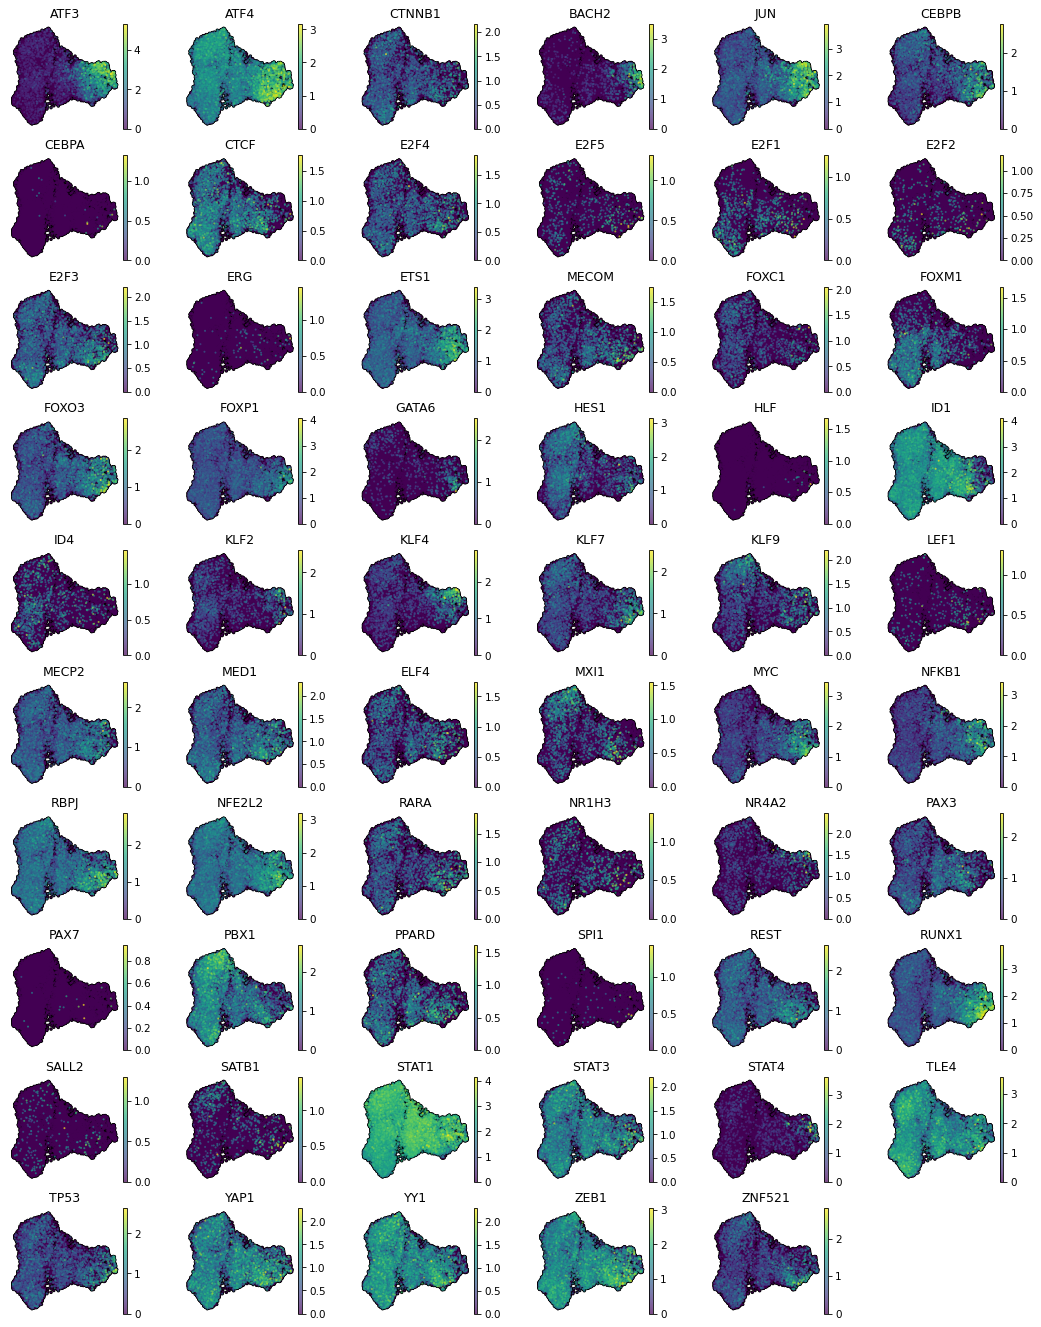

In [34]:
plt.rcParams['figure.dpi'] = 75
plt.rcParams['figure.figsize'] = 2, 2

sc.pl.umap(
    adata,
    color=qui_tfs,
    ncols=6,
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    # alpha=0.8,
    layer='log_norm',
)

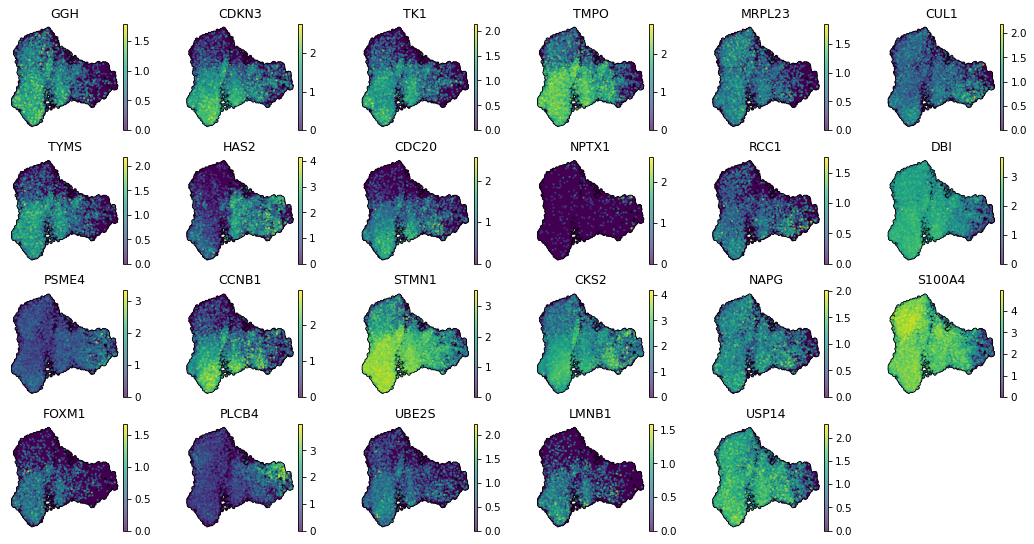

In [35]:
qui_down_genes = [g for g in qui_down_genes if g in adata.var_names]

sc.pl.umap(
    adata,
    color=qui_down_genes,
    ncols=6,
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    # alpha=0.8,
    layer='log_norm',
)

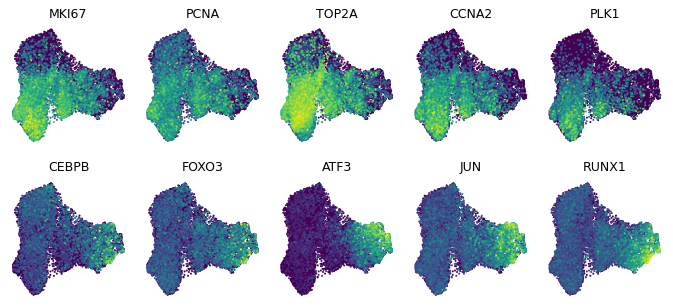

In [53]:
plt.rcParams['figure.dpi'] = 75
plt.rcParams['figure.figsize'] = 2, 2.25

genes = [
    # proliferative markers / down in quiescence
    'MKI67', 'PCNA', 'TOP2A', 'CCNA2', 'PLK1',
    # up in quiescence
    'CEBPB', 'FOXO3', 'ATF3', 'JUN', 'RUNX1',
]

sc.pl.umap(
    adata,
    color=genes,
    ncols=5,
    size=15,
    # add_outline=True,
    # outline_color=('k', 'k'),
    frameon=False, 
    alpha=1,
    layer='log_norm',
    colorbar_loc=None,
    hspace=0.25,
    wspace=0.1,
    
)

In [39]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [40]:
[col for col in geneset.columns if 'G0' in col]

['Regulation of G0 to G1 Transition (GO:0070316)']

In [41]:
genes = geneset['Regulation of G0 to G1 Transition (GO:0070316)'].unique().tolist()
print(len(genes))
genes

34


['SMARCC1',
 'SMARCC2',
 'CDKN2B',
 'PBRM1',
 'PHF10',
 'RRM1',
 'ACTL6B',
 'SMARCE1',
 'SOX15',
 'ARID1A',
 'ARID1B',
 'HLA-G',
 'SMARCA2',
 'SMARCA4',
 'DAB2IP',
 'RRM2B',
 'RHNO1',
 'SMARCD1',
 'SMARCD2',
 'SMARCB1',
 'SMARCD3',
 'DUX4',
 'FOXO4',
 'BCL7B',
 'CHEK1',
 'BCL7A',
 'DPF1',
 'BCL7C',
 'DPF2',
 'DPF3',
 'POTEF',
 'BRD7',
 'ARID2',
 None]

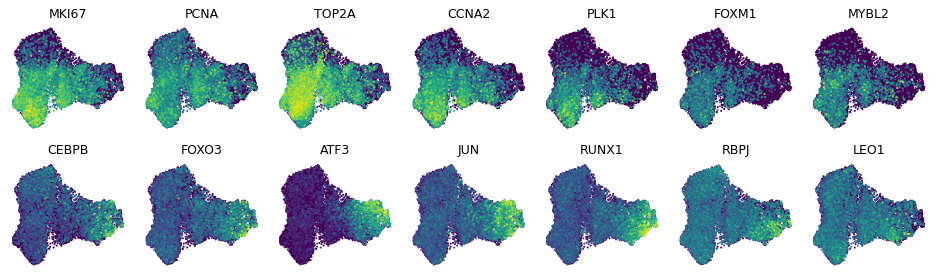

In [54]:
plt.rcParams['figure.dpi'] = 75
plt.rcParams['figure.figsize'] = 2, 2

genes = [
    # proliferative markers / down in quiescence
    'MKI67', 'PCNA', 'TOP2A', 'CCNA2', 'PLK1', 'FOXM1', 'MYBL2',
    # up in quiescence
    'CEBPB', 'FOXO3', 'ATF3', 'JUN', 'RUNX1', 'RBPJ', 'LEO1', 
]

sc.pl.umap(
    adata,
    color=genes,
    ncols=7,
    size=15,
    # add_outline=True,
    # outline_color=('k', 'k'),
    frameon=False, 
    alpha=1,
    layer='log_norm',
    colorbar_loc=None,
    hspace=0.25,
    wspace=0.1,
    
)

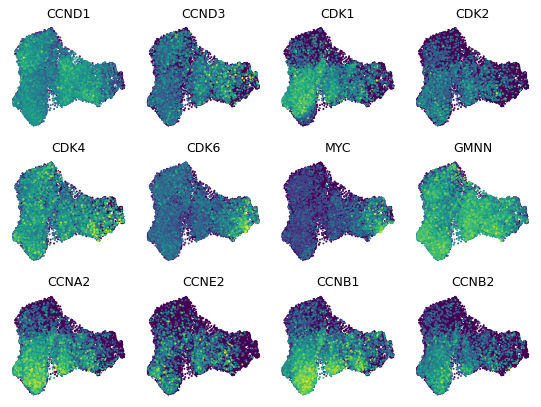

In [55]:
plt.rcParams['figure.dpi'] = 75
plt.rcParams['figure.figsize'] = 2, 2

genes = [
    'CCND1', 'CCND3', 'CDK1', 'CDK2', 'CDK4', 'CDK6',
    'MYC', 'GMNN', 'CCNA2', 'CCNE2', 'CCNB1', 'CCNB2',
]

sc.pl.umap(
    adata,
    color=genes,
    ncols=4,
    size=15,
    # add_outline=True,
    # outline_color=('k', 'k'),
    frameon=False, 
    alpha=1,
    layer='log_norm',
    colorbar_loc=None,
    hspace=0.25,
    wspace=0.1,
    
)

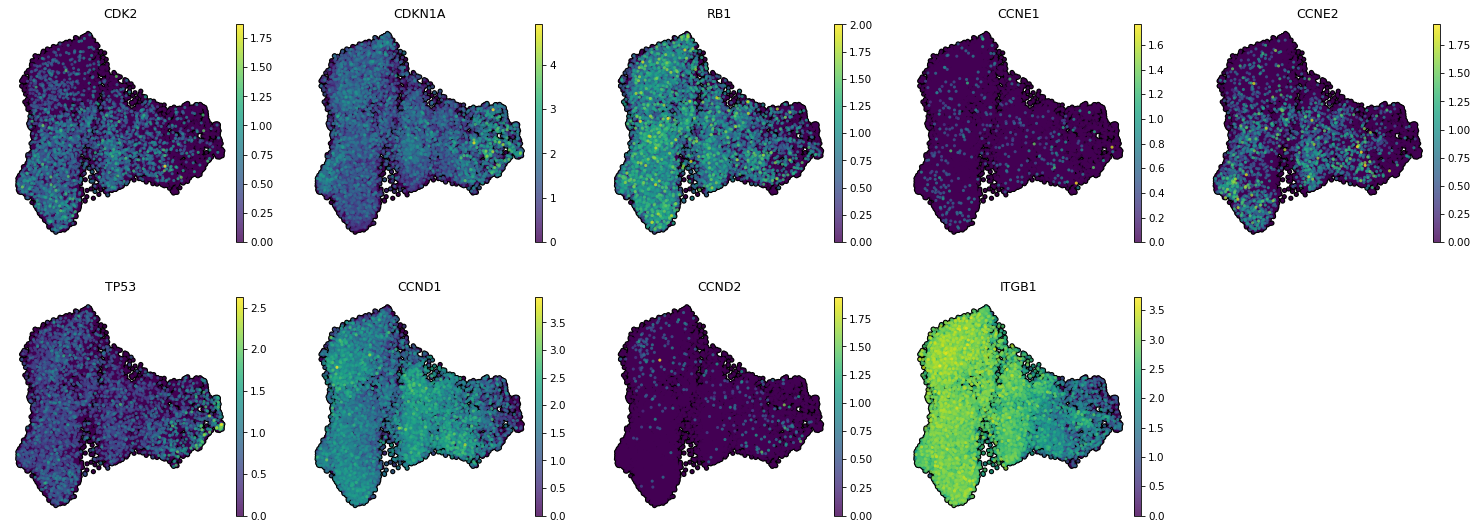

In [56]:
plt.rcParams['figure.dpi'] = 75
plt.rcParams['figure.figsize'] = 4, 4

genes_to_plot = ['CDK2', 'CDKN1A', 'RB1', 'CCNE1', 'CCNE2',
                 'TP53', 'CCND1', 'CCND2', 'ITGB1'
                ]

sc.pl.umap(
    adata,
    color=genes_to_plot,
    ncols=5,
    size=35,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.8,
    layer='log_norm',
)

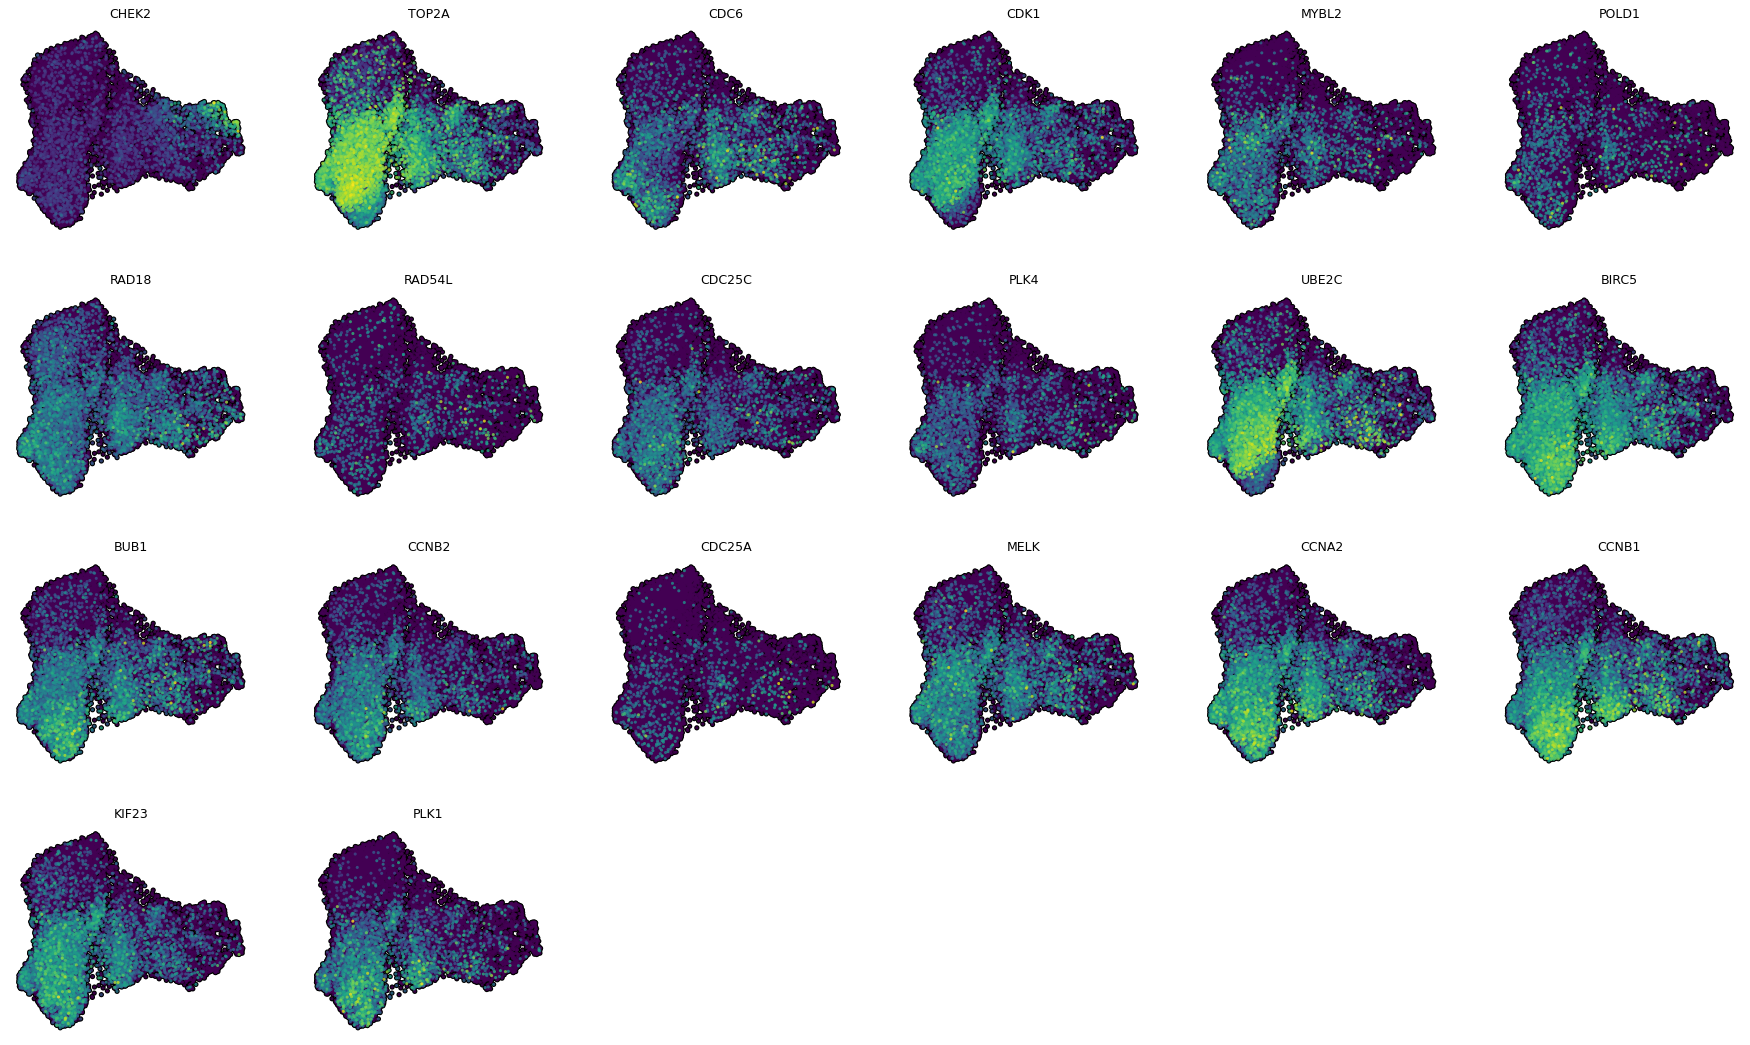

In [57]:
genes_to_plot = [
    # DREAM target genes
    'CHEK2', 'TOP2A', 'CDC6', 'CDK1', 'MYBL2', 'POLD1', 'RAD18', 'RAD54L', 'CDC25C',
    'PLK4', 'UBE2C', 'BIRC5', 'BUB1', 'CCNB2', 'CDC25A', 'MELK', 'CCNA2', 'CCNB1', 'KIF23', 'PLK1'
]

plt.rcParams['figure.dpi'] = 75
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=genes_to_plot,
    ncols=6,
    size=35,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.8,
    layer='log_norm',
    colorbar_loc=None,
)

(10, 4)


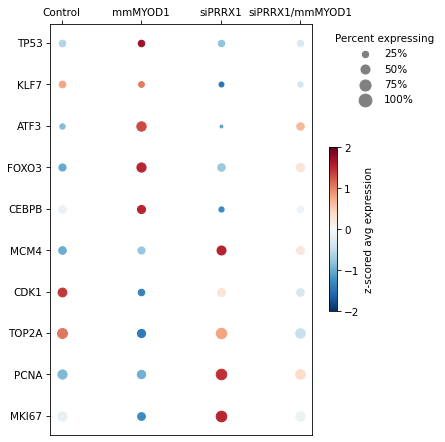

In [58]:
genes = [
    # proliferative markers / down in quiescence
    'MKI67', 'PCNA', 'TOP2A', 'CDK1', 'MCM4',
    # up in quiescence
    'CEBPB', 'FOXO3', 'ATF3', 'KLF7', 'TP53',
]
    

genes_to_plot = [g for g in genes if g in adata.var_names]

groups = adata.obs['pooled_condition'].unique()
groups = sorted(groups)

avg_expr = pd.DataFrame(index=genes_to_plot, columns=groups)
pct_expr = pd.DataFrame(index=genes_to_plot, columns=groups)

adata.X = adata.layers['log_norm'].copy()

for g in groups:
    cells = adata.obs['pooled_condition'] == g
    data = adata[cells, genes_to_plot].X
    # If sparse matrix
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    avg_expr[g] = data.mean(axis=0)
    pct_expr[g] = (data > 0).mean(axis=0) * 100

# Z-score by gene
avg_expr = avg_expr.T   
avg_expr_z = avg_expr.apply(scipy.stats.zscore, axis=0)
avg_expr_z = avg_expr_z.T

print(avg_expr_z.shape)
avg_expr_z.head()  

cmap = 'RdBu_r'
size_scale = 1.5

plt.rcParams['figure.dpi'] = 75
plt.rcParams['figure.figsize'] = 6, 6
fig, ax = plt.subplots()

for i, gene in enumerate(genes_to_plot):
    for j, cluster in enumerate(groups):
        size = float(pct_expr.loc[gene, cluster])*size_scale
        color = float(avg_expr_z.loc[gene, cluster])
        
        ax.scatter(
            x=j, 
            y=i, 
            s=size, 
            c=[color], 
            cmap=cmap,
            vmin=-2, 
            vmax=2, 
        )
        
ax.set_yticks(range(len(genes_to_plot)))
ax.set_yticklabels(genes_to_plot)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups)
ax.xaxis.set_label_position('top') 
ax.xaxis.tick_top()
ax.set_xlabel('')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-2, vmax=2))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.05)
cbar.set_label('z-scored avg expression')


sizes = [25, 50, 75, 100]
markers = [plt.scatter([], [], s=s*size_scale, color='gray') for s in sizes]
labels = [f"{s}%" for s in sizes]

ax.legend(markers, labels, title="Percent expressing", scatterpoints=1,
          frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

(512, 18)
['G1/S_transition', 'G2/M_transition', 'CC_checkpoints', 'Cell_cycle_reg', 'Pos_proliferation', 'Neg_proliferation', 'quiescence', 'AS', 'Chromatin', 'Circadian', 'Core_repro', 'NOTCH_signaling', 'Asymm_PCP', 'FOXO', 'p53_acyivity', 'DREAM/negE2F', 'senes_stress', 'sasp']
52
computing score 'circadian_score'
    finished (0:00:02)


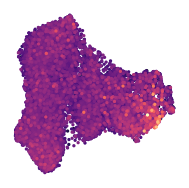

In [59]:
fpath = "../../resources/genes_for_scoring.csv"

df = pd.read_csv(fpath)
print(df.shape)
print(df.columns.tolist())
df.head()

circ_genes = [gene for gene in df['Circadian'].unique() if gene in adata.var_names]
print(len(circ_genes))

sc.tl.score_genes(
    adata,
    gene_list=circ_genes,
    score_name='circadian_score',
    ctrl_size=500,
    use_raw=False,
    layer='log_norm',
)

plt.rcParams['figure.dpi'] = 75
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    color=['circadian_score'],
    size=40,
    ncols=1,
    # add_outline=True,
    # outline_color=('k', 'k'),
    colorbar_loc=None,
    frameon=False,
    alpha=1,
    cmap='magma',
    title='',
)

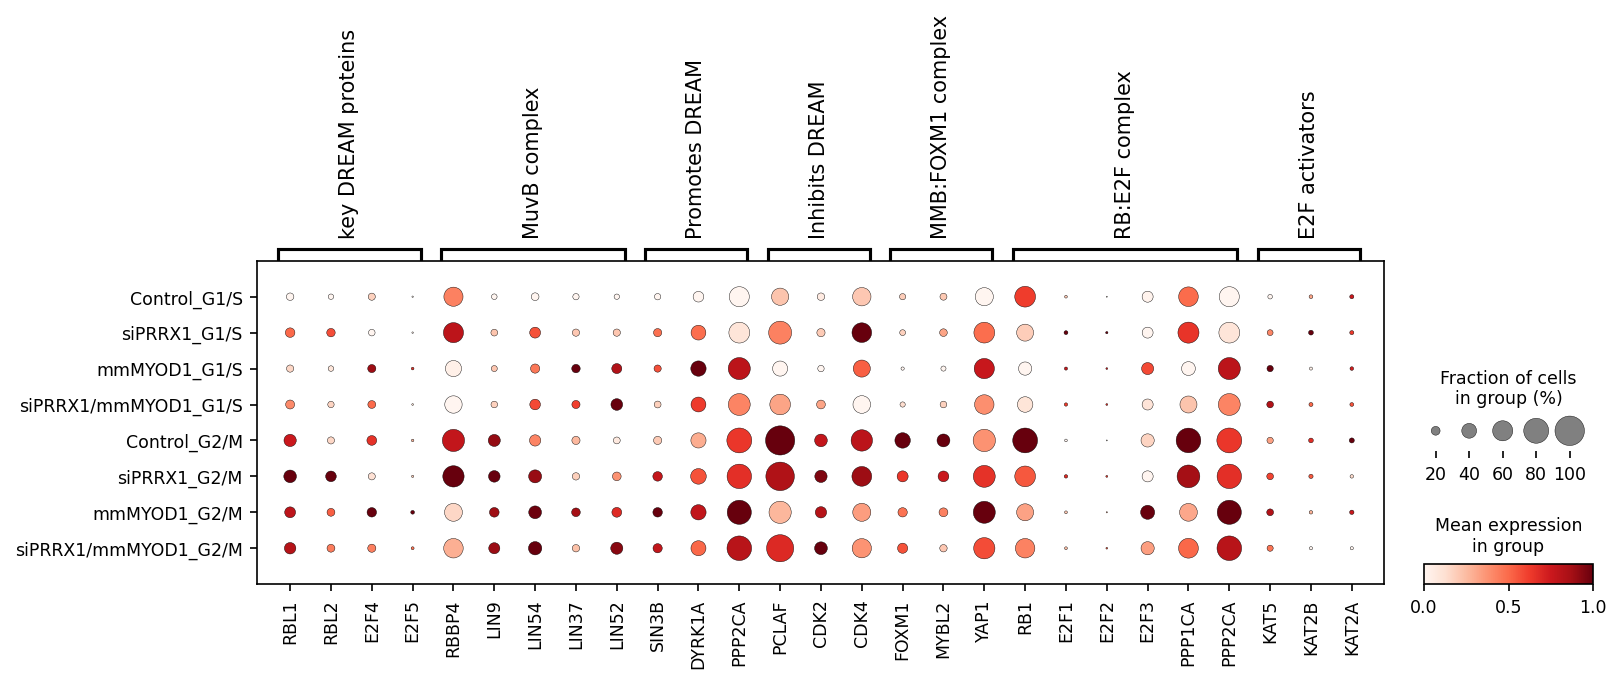

In [49]:
genes = {
    'key DREAM proteins': ['RBL1', 'RBL2', 'E2F4', 'E2F5'], # key proteins
    'MuvB complex': ['RBBP4', 'LIN9', 'LIN54', 'LIN37', 'LIN52'], # MuvB complex
    'Promotes DREAM': ['SIN3B', 'DYRK1A', 'PPP2CA'], # promotes DREAM
    'Inhibits DREAM': ['PCLAF', 'CDK2', 'CDK4'], # inhibits DREAM
    'MMB:FOXM1 complex': ['FOXM1', 'MYBL2', 'YAP1'], # MMB:FOXM1 complex (YAP stimulates MMB formation)
    'RB:E2F complex': ['RB1', 'E2F1', 'E2F2', 'E2F3', 'PPP1CA', 'PPP2CA'],
    'E2F activators': ['KAT5', 'KAT2B', 'KAT2A'],
}
    
# genes_to_plot = [gene for gene in genes.items if gene in adata.var_names]

# order = ['Control_G1/S', 'Control_G2/M', 'mmMYOD1_G1/S', 'mmMYOD1_G2/M', 'siPRRX1_G1/S', 'siPRRX1_G2/M', 'siPRRX1/mmMYOD1_G1/S', 'siPRRX1/mmMYOD1_G2/M']
order = ['Control_G1/S', 'siPRRX1_G1/S', 'mmMYOD1_G1/S', 'siPRRX1/mmMYOD1_G1/S', 'Control_G2/M', 'siPRRX1_G2/M', 'mmMYOD1_G2/M', 'siPRRX1/mmMYOD1_G2/M']

sc.pl.dotplot(
    adata,
    groupby='condition_by_phase_group',
    var_names=genes,
    layer='log_norm',
    # title=pathway,
    standard_scale='var',
    categories_order=order,
)